# P1 · Modules, parameters, and model state

Unit 0 foundations for the current Tiny Transformer and the later Phyll course. Basic Python variables, loops and functions are assumed.

Download and open this notebook in Jupyter, or choose **File → Upload notebook** in Google Colab. All examples and the required helper code are included. No account key, private repository, GPU or dataset download is needed.

Examples are **illustrative**, executed with Python and PyTorch. Newly constructed model weights are explicitly untrained. Run from a fresh kernel in order. Each exercise can run before you fill it in; open its folded solution afterward.

The `show` helper prints named intermediate results. It is course code, not a built-in Python or PyTorch function.

In [1]:
import sys, math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
torch.set_num_threads(1)
torch.manual_seed(7)
print("Python", sys.version.split()[0], "· PyTorch", torch.__version__, "· CPU")
print("Reference environment: Python 3.12 / PyTorch 2.10. Run with Colab's installed PyTorch or the course requirements.txt.")


Python 3.12.3 · PyTorch 2.10.0+cpu · CPU
Reference environment: Python 3.12 / PyTorch 2.10. Run with Colab's installed PyTorch or the course requirements.txt.


Publication destination: the [public course labs repository](https://github.com/gkiri/tiny_repo). This notebook includes its own examples and can run before that mirror is published.

In [2]:
#@title Display helper: print and draw executed values { display-mode: "form" }
"""Small display helper embedded verbatim in independent notebooks; traces record real executions."""
import json
import math

FRAMES = []


def plain(value):
    if hasattr(value, "detach"):
        return plain(value.detach().cpu().tolist())
    if isinstance(value, dict):
        return {str(k): plain(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [plain(v) for v in value]
    if isinstance(value, float) and not math.isfinite(value):
        return str(value)
    if value is None or isinstance(value, (str, int, float, bool)):
        return value
    return str(value)


def show(label, value):
    """Print and snapshot an intermediate. This helper is course code, not a PyTorch API."""
    frame = {"label": label, "value": plain(value)}
    if hasattr(value, "shape"):
        frame.update(shape=list(value.shape), dtype=str(value.dtype), device=str(value.device))
    FRAMES.append(frame)
    print(label + ":", json.dumps(frame["value"], ensure_ascii=False))
    if "shape" in frame:
        print("  shape", frame["shape"], "·", frame["dtype"], "·", frame["device"])


def draw_trace():
    """A portable SVG trace diagram; requires only the notebook's existing IPython display."""
    import html
    from IPython.display import SVG, display
    height = 82 * len(FRAMES) + 12
    parts = [f'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 720 {height}" role="img" aria-label="Executed intermediate values">']
    for i, frame in enumerate(FRAMES):
        y = 8 + 82*i
        value = json.dumps(frame["value"], ensure_ascii=False)
        if len(value) > 91:
            value = value[:88] + "…"
        parts += [f'<rect x="4" y="{y}" width="708" height="68" rx="10" fill="#f4f8ef" stroke="#779861"/>',
                  f'<text x="20" y="{y+25}" font-size="15" font-family="sans-serif" fill="#31524b">{i+1}. {html.escape(frame["label"])}</text>',
                  f'<text x="20" y="{y+48}" font-size="12" font-family="monospace" fill="#252a33">{html.escape(value)}</text>']
        if i + 1 < len(FRAMES):
            parts.append(f'<path d="M360 {y+68} v14" stroke="#7042a6" stroke-width="2"/>')
    display(SVG("".join(parts) + "</svg>"))

## P1.10 · Modules, parameters, and model state

Modules register learned parameters and buffers. Shared parameters are one object even when several modules use them.

**Prerequisites:** Embeddings and positions

**Predict:** What proves two layers are tied?

**Mental model:** A neural network module combines a calculation with registered state. Registration lets the library find parameters for optimization, device movement and saving.

<a data-compat-cell="p1-modules"></a>

### Why this operation exists

A neural network module combines a calculation with registered state. Registration lets the library find parameters for optimization, device movement and saving.

An ordinary tensor attribute is not automatically a learned parameter. Parameter marks a tensor for that role, while buffers represent other module state.

A list of layers also needs registration. ModuleList keeps its contained layers visible to the parent module's parameter traversal.

Weight tying deliberately makes two uses refer to one parameter object. Counting names in a saved dictionary can therefore differ from counting unique learned values.

Inspect registration before training. A calculation may run while an accidentally unregistered weight never reaches the optimizer.

### Follow the values

The model holds a four-entry embedding, a small linear transformation and a four-entry output bias. The parameter listing shows their individual shapes.

The allowed tensor appears among buffers. It moves with the module but is not a learned parameter, and this nonpersistent buffer is excluded from the saved state dictionary.

The readout weight refers to the embedding's parameter object. Identity is true: these are two uses of shared state.

With width three, the unique parameter count is twenty-eight. The shared embedding contributes twelve, the transformation twelve, and the output bias four.

Calling the module on one sequence of two IDs returns one-by-two-by-four scores. Increase width in the experiment and recount the internal state while preserving the output vocabulary size.

In [3]:
FRAMES.clear()
change = 0
torch.manual_seed(7)
class TinyLookup(nn.Module):
    def __init__(self, width):
        super().__init__()
        self.embedding = nn.Embedding(4, width)
        self.readout = nn.Linear(width, 4, bias=False)
        self.readout.weight = self.embedding.weight
        self.bias = nn.Parameter(torch.zeros(4))
        self.layers = nn.ModuleList([nn.Linear(width, width)])
        self.register_buffer("allowed", torch.ones(2,2,dtype=torch.bool), persistent=False)
    def forward(self, ids):
        x = self.embedding(ids)
        for layer in self.layers:
            x = layer(x)
        return self.readout(x) + self.bias
model = TinyLookup(4 if change else 3)
show("Registered parameter shapes", {n: list(p.shape) for n,p in model.named_parameters()})
show("Buffer names", [n for n,_ in model.named_buffers()])
show("Readout and embedding share one object", model.readout.weight is model.embedding.weight)
show("Unique parameter elements", sum(p.numel() for p in model.parameters()))
show("Call forward through the module", model(torch.tensor([[1,2]])).shape)

Registered parameter shapes: {"bias": [4], "embedding.weight": [4, 3], "layers.0.weight": [3, 3], "layers.0.bias": [3]}
Buffer names: ["allowed"]
Readout and embedding share one object: true
Unique parameter elements: 28
Call forward through the module: [1, 2, 4]


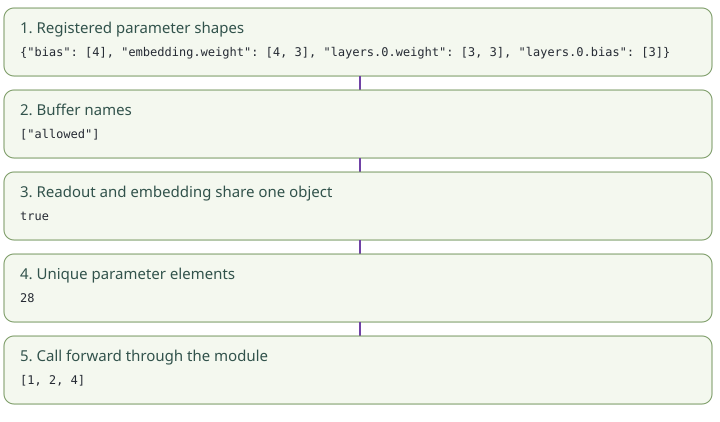

In [4]:
draw_trace()

### Read the implementation

Initialize the module base class with super before assigning registered submodules. The inherited machinery tracks those assignments.

Embedding and Linear create their own parameters. Wrapping the output bias in Parameter makes this explicitly created tensor discoverable too.

Assign the embedding parameter to the readout weight to share it. Copying equal numbers into an independent weight would not create the same relationship.

ModuleList registers the layer objects, but your forward method still decides how to call them. Sequential instead provides an ordered call chain for compatible modules.

Call model with parentheses so module call behavior surrounds forward. Use named parameters and named buffers to audit the state that saving and device movement will use.

### Change one thing

**Increase the illustrative feature width**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [5]:
FRAMES.clear()
change = 1
torch.manual_seed(7)
class TinyLookup(nn.Module):
    def __init__(self, width):
        super().__init__()
        self.embedding = nn.Embedding(4, width)
        self.readout = nn.Linear(width, 4, bias=False)
        self.readout.weight = self.embedding.weight
        self.bias = nn.Parameter(torch.zeros(4))
        self.layers = nn.ModuleList([nn.Linear(width, width)])
        self.register_buffer("allowed", torch.ones(2,2,dtype=torch.bool), persistent=False)
    def forward(self, ids):
        x = self.embedding(ids)
        for layer in self.layers:
            x = layer(x)
        return self.readout(x) + self.bias
model = TinyLookup(4 if change else 3)
show("Registered parameter shapes", {n: list(p.shape) for n,p in model.named_parameters()})
show("Buffer names", [n for n,_ in model.named_buffers()])
show("Readout and embedding share one object", model.readout.weight is model.embedding.weight)
show("Unique parameter elements", sum(p.numel() for p in model.parameters()))
show("Call forward through the module", model(torch.tensor([[1,2]])).shape)

Registered parameter shapes: {"bias": [4], "embedding.weight": [4, 4], "layers.0.weight": [4, 4], "layers.0.bias": [4]}
Buffer names: ["allowed"]
Readout and embedding share one object: true
Unique parameter elements: 40
Call forward through the module: [1, 2, 4]


### A useful distinction

Equal tensor values do not establish weight tying. Shared parameters must refer to the same learned object.

### ✋ Your turn

Create nn.Linear(3,2) with its default bias and put its parameter element count in answer.

In [6]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == 8, 'Equal tensor values do not establish weight tying. Shared parameters must refer to the same learned object.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [7]:
#@title Show a solution { display-mode: "form" }
layer = nn.Linear(3,2)
answer = sum(p.numel() for p in layer.parameters())

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == 8, 'Equal tensor values do not establish weight tying. Shared parameters must refer to the same learned object.'
    print("✓ right:", answer)

✓ right: 8


### Reconnect to the transformer

Our current model registers token and position embeddings, transformer blocks, a final normalization layer and a vocabulary bias. Its readout directly reuses the token-table weight.

The causal mask is a nonpersistent buffer. It is derived from configuration, can move to the model's device, and need not be learned or stored as a parameter.

Initialization assigns starting values to parameters before training. A parameter is learnable state, not evidence that it has already been trained.

Phyll uses a registered list of blocks and explicitly ties its readout weight to the embedding. The same registration and identity checks apply.

Next, use these registered projections to assemble the actual attention tensors.

```python
self.head_bias = nn.Parameter(torch.zeros(cfg.vocab_size))
logits = x @ self.tok_emb.weight.T + self.head_bias
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** What proves two layers are tied?

<details><summary>Check your explanation</summary>

They share the same parameter object. Equal tensor values do not establish weight tying. Shared parameters must refer to the same learned object.

</details>